In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. DATASET OVERVIEW
Total Rows (Records): 5572
Total Columns: 2
Column Names: ['label', 'message']

2. CLASS DISTRIBUTION
label
ham     4825
spam     747
Name: count, dtype: int64

Percentages:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

3. MISSING & DUPLICATE VALUES
Missing Values per Column:
label      0
message    0
dtype: int64

Total Duplicate Rows: 403

4. EXAMPLE MESSAGES
--- HAM EXAMPLES ---
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
2. Ok lar... Joking wif u oni...

--- SPAM EXAMPLES ---
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv


/tmp/ipykernel_1094/3588485113.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'])


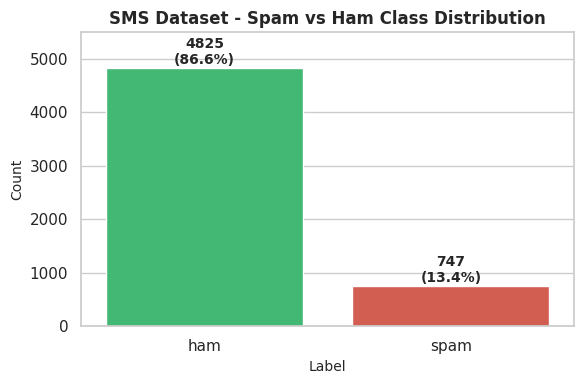

In [ ]:
# ======================================================
# WEEK 1 TASK 3: SMS DATASET ANALYSIS (EDA) - MALSHA
# ======================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Update this path to the correct location of your CSV file in Google Drive
df = pd.read_csv('/content/drive/MyDrive/sms_spam_collection (sms).csv')

# 2. Inspect total rows, columns, and column names
print("==========================================")
print("1. DATASET OVERVIEW")
print("==========================================")
print(f"Total Rows (Records): {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Column Names: {list(df.columns)}")

# 3. Analyze class distribution (Spam vs Ham)
print("\n==========================================")
print("2. CLASS DISTRIBUTION")
print("==========================================")
print(df['label'].value_counts())
print("\nPercentages:")
print(df['label'].value_counts(normalize=True) * 100)

# 4. Check for missing values and duplicate records
print("\n==========================================")
print("3. MISSING & DUPLICATE VALUES")
print("==========================================")
print(f"Missing Values per Column:\n{df.isnull().sum()}")
print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")

# 5. Display sample Spam and Ham messages
print("\n==========================================")
print("4. EXAMPLE MESSAGES")
print("==========================================")
print("--- HAM EXAMPLES ---")
for idx, msg in enumerate(df[df['label'] == 'ham']['message'].head(2), 1):
    print(f"{idx}. {msg}")

print("\n--- SPAM EXAMPLES ---")
for idx, msg in enumerate(df[df['label'] == 'spam']['message'].head(2), 1):
    print(f"{idx}. {msg}")

# 6. Generate and display the class distribution chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('SMS Dataset - Spam vs Ham Class Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Label', fontsize=10)
plt.ylabel('Count', fontsize=10)

# Annotate counts and percentages on top of each bar
for p in ax.patches:
    count = int(p.get_height())
    percentage = f"{count / len(df) * 100:.1f}%"
    ax.annotate(f'{count}\n({percentage})',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 12), textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.ylim(0, 5500)
plt.tight_layout()
plt.show()


In [ ]:

# ======================================================
# WEEK 1 TASK 4: SMS DATASET PREPROCESSING - MALSHA
# ======================================================

import pandas as pd
import re
import nltk

# Download necessary NLTK datasets
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 1. Load original SMS dataset
df = pd.read_csv('/content/drive/MyDrive/sms_spam_collection (sms).csv')

# Initialize Lemmatizer and Stopwords list
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 2. Define Preprocessing Function
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # Step A: Convert to Lowercase
    text = text.lower()

    # Step B: Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Step C: Remove HTML Tags
    text = re.sub(r'<.*?>', '', text)

    # Step D: Remove Numbers
    text = re.sub(r'\d+', '', text)

    # Step E: Remove Punctuation & Special Characters
    text = re.sub(r'[^\w\s]', '', text)

    # Step F: Remove Extra Whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step G: Tokenize, Remove Stop Words, and Lemmatize
    tokens = text.split()
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return ' '.join(cleaned_tokens)

# 3. Apply preprocessing
df['cleaned_message'] = df['message'].apply(preprocess_text)

# 4. Filter out any rows that became empty after cleaning
df_cleaned = df[df['cleaned_message'].str.strip() != ''].copy()

# 5. Display Before & After Examples
print("==========================================")
print("PREPROCESSING EXAMPLES (BEFORE vs AFTER)")
print("==========================================")
sample_df = df_cleaned[['label', 'message', 'cleaned_message']].head(5)

for idx, row in sample_df.iterrows():
    print(f"[{row['label'].upper()}]")
    print(f"BEFORE : {row['message']}")
    print(f"AFTER  : {row['cleaned_message']}")
    print("-" * 60)

# 6. Save the final cleaned dataset as Deliverable
output_df = df_cleaned[['label', 'cleaned_message']].rename(columns={'cleaned_message': 'message'})
output_df.to_csv('/content/sample_data/cleaned_sms_dataset.csv', index=False)

print("\nSUCCESS: Cleaned dataset saved as '/content/sample_data/cleaned_sms_dataset.csv'!")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


PREPROCESSING EXAMPLES (BEFORE vs AFTER)
[HAM]
BEFORE : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
AFTER  : go jurong point crazy available bugis n great world la e buffet cine got amore wat
------------------------------------------------------------
[HAM]
BEFORE : Ok lar... Joking wif u oni...
AFTER  : ok lar joking wif u oni
------------------------------------------------------------
[SPAM]
BEFORE : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
AFTER  : free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply over
------------------------------------------------------------
[HAM]
BEFORE : U dun say so early hor... U c already then say...
AFTER  : u dun say early hor u c already say
------------------------------------------------------------
[HAM]
BEFORE : Nah I

In [ ]:

df['clean_text'] = df['message'].apply(preprocess_text)


df.to_csv('cleaned_sms_dataset.csv', index=False)
print("File Saved Successfully!")

File Saved Successfully!


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
df_sms = pd.read_csv('/content/drive/MyDrive/cleaned_sms_dataset.csv')
df_email = pd.read_csv('/content/drive/MyDrive/cleaned_email_dataset.csv')
df_youtube = pd.read_csv('/content/drive/MyDrive/youtube_cleaned_final.csv')

In [27]:
import pandas as pd
from google.colab import files

# 1. Read cleaned datasets from all 3 members
df_sms = pd.read_csv('/content/drive/MyDrive/cleaned_sms_dataset.csv')
df_email = pd.read_csv('/content/drive/MyDrive/cleaned_email_dataset.csv')
df_youtube = pd.read_csv('/content/drive/MyDrive/youtube_cleaned_final.csv')

# 2. Add platform source tag
df_sms['source'] = 'SMS'
df_email['source'] = 'Email'
df_youtube['source'] = 'YouTube'

# 3. Standardize labels for YouTube (0 to ham, 1 to spam)
if 'label' in df_youtube.columns:
    df_youtube['label'] = df_youtube['label'].replace({0: 'ham', 1: 'spam'})

# 4. Merge/Concatenate all 3 datasets together
combined_df = pd.concat([df_sms, df_email, df_youtube], ignore_index=True)

# 5. Display Summary
print("==========================================")
print("COMBINED DATASET SUMMARY")
print("==========================================")
print(f"Total Rows: {len(combined_df)}")
print("\nData distribution by source:")
print(combined_df['source'].value_counts())
print("\nFirst 5 rows:")
print(combined_df.head())

# 6. Save combined dataset to CSV
output_filename = 'combined_clean_dataset.csv'
combined_df.to_csv(output_filename, index=False)
print(f"\nSaved successfully as '{output_filename}'")

# 7. Download to your computer automatically
files.download(output_filename)

COMBINED DATASET SUMMARY
Total Rows: 11893

Data distribution by source:
source
SMS        5566
Email      4845
YouTube    1482
Name: count, dtype: int64

First 5 rows:
  label                                            message source text  class
0   ham  go jurong point crazy available bugis n great ...    SMS  NaN    NaN
1   ham                            ok lar joking wif u oni    SMS  NaN    NaN
2  spam  free entry wkly comp win fa cup final tkts st ...    SMS  NaN    NaN
3   ham                u dun say early hor u c already say    SMS  NaN    NaN
4   ham           nah dont think go usf life around though    SMS  NaN    NaN

Saved successfully as 'combined_clean_dataset.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>